<a href="https://colab.research.google.com/github/mkhanamm/Machine-Learning-for-Algorithmic-Trading-Second-Edition_Original/blob/master/IR_ASSIGN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
text = "भारत, एक सुंदर देश है! भारत में कई भाषाएँ बोली जाती हैं।"
import re     #regular expressions(find &replace patterns)
text = re.sub(r'[^\u0900-\u097F\s]', '', text)   #match anything not a word or space and replace"

 re.sub(WHAT_TO_FIND, REPLACE_WITH, TEXT
 )
 unicode safe cleaning! removing exlamations etc..

 \w
means: letters + numbers + underscore
re.sub(r'[^\w\s]', '', text)


👉 \w does NOT properly support Hindi characters
\u0900-\u097F = full Hindi Unicode range


* Unicode-safe cleaning*

In [ ]:
words = text.split() #tokenization:sentance to words

stopwords = {
    "एक", "है", "में", "और", "के", "का", "की", "को",
    "पर", "से", "तक", "भी", "ही", "था", "थे", "हैं",
    "यह", "वह", "जो", "कि", "तो", "था", "थी", "थे",
    "हो", "रहा", "रही", "रहे", "गया", "गई", "गए"
}

''' If user searches:

भारत

You don’t care about:

है, में, एक
👉 Removing them = better search + smaller data'''

In [ ]:
def remove_stopwords(words):
    filtered = []
    for word in words:
        if word not in stopwords:
            filtered.append(word)
    return filtered

filtered_words = remove_stopwords(words)

print("Before: ", words)
print("After:", filtered_words)

print("Count before", len(words))
print("count after:", len(filtered_words))

vocab = set(filtered_words) #removes duplicates
print("vocabulary: ", vocab)
print("Vocabulary size:", len(vocab))

Before:  ['भारत', 'एक', 'सुंदर', 'देश', 'है', 'भारत', 'में', 'कई', 'भाषाएँ', 'बोली', 'जाती', 'हैं।']
After: ['भारत', 'सुंदर', 'देश', 'भारत', 'कई', 'भाषाएँ', 'बोली', 'जाती', 'हैं।']
Count before 12
count after: 9
vocabulary:  {'देश', 'हैं।', 'भारत', 'भाषाएँ', 'बोली', 'जाती', 'सुंदर', 'कई'}
Vocabulary size: 8


In [ ]:
from collections import Counter
freq = Counter(filtered_words)

print("Word Frequencies")
for word, count in freq.items():
    print(word, ":", count)

Word Frequencies
भारत : 2
सुंदर : 1
देश : 1
कई : 1
भाषाएँ : 1
बोली : 1
जाती : 1
हैं। : 1


In [ ]:
sorted_freq = sorted(freq.items(), key=lambda x: x[1], reverse=True)

print(sorted_freq)

[('भारत', 2), ('सुंदर', 1), ('देश', 1), ('कई', 1), ('भाषाएँ', 1), ('बोली', 1), ('जाती', 1), ('हैं।', 1)]


freq is in the form of a dictionary..which is unordered.. nd needs to be sorted

so its converted to a list, using items(),converts the pairs in
 a dictionary to a set of tuples..nd those tuples in list.

 SORTED: ( list.sort()) is used to sort the current list..

 SORTED is used to sort the items nd put in a new list.

 When used in a context like sorted(my_list, key=lambda x: x[1]), the code:

Iterates through each element (x) in my_list.

Applies the lambda function to that element, extracting its second item (x[1]).

Sorts my_list based on these extracted second items, not the entire original elements.



In [ ]:
#prepare graph data: converting data into graph-ready format
ranks = []
frequencies = []

for i, (word, count) in enumerate(sorted_freq):
    ranks.append(i + 1)
    frequencies.append(count)

print("Ranks:", ranks)
print("Frequencies:", frequencies)

Ranks: [1, 2, 3, 4, 5, 6, 7, 8]
Frequencies: [2, 1, 1, 1, 1, 1, 1, 1]


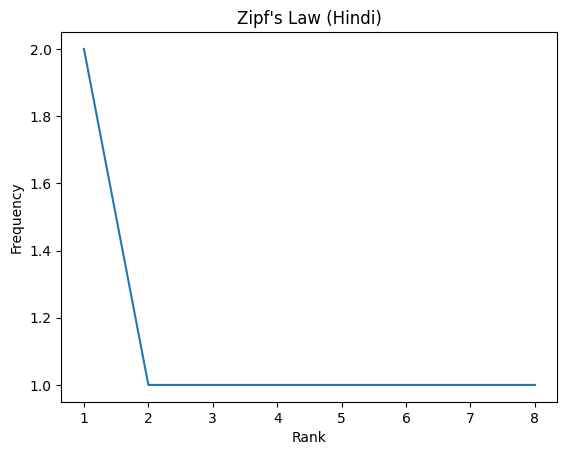

In [ ]:
#PLOT GRAPH 📈
import matplotlib.pyplot as plt

plt.plot(ranks, frequencies)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law (Hindi)")
plt.show()

[Zipf's Law](https://www.geeksforgeeks.org/nlp/zipfs-law/)

Zip's law describes the relationship betweenthe **frequency of words** in language corpus and their **rank** in a frequency sorted list.

Which says:

👉 “Word frequency decreases as rank increases”

We notice that the plot roughly follows the pattern of the reciprocal function y=1/x.

 As x increases, y decreases. If the numerical value of rank is high, the frequency is low.

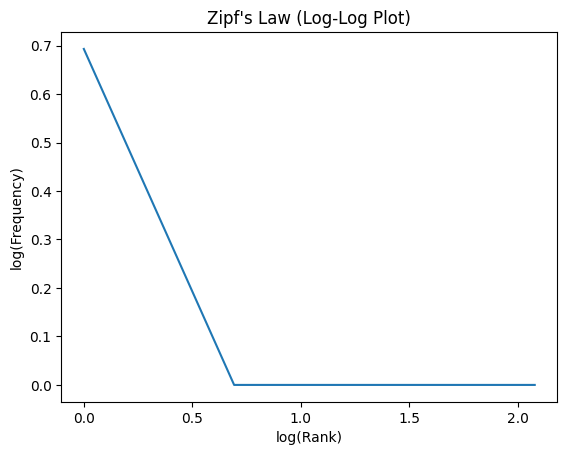

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

log_ranks = np.log(ranks)
log_freq = np.log(frequencies)

plt.plot(log_ranks, log_freq)
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.title("Zipf's Law (Log-Log Plot)")
plt.show()

Log-log graph helps us clearly see Zipf’s pattern as a straight line

In [ ]:
total_words = []
vocab_size = []

seen_words = set()

for i, word in enumerate(filtered_words):
    seen_words.add(word)

    total_words.append(i + 1)
    vocab_size.append(len(seen_words))

**HEAPS LAW**
Heaps' law demonstrates that as you read more text, the probability of encountering a new word decreases,

 but due to new entity names or misspellings, the vocabulary size keeps growing. It differs from Zipf's law, which describes the frequency of individual words


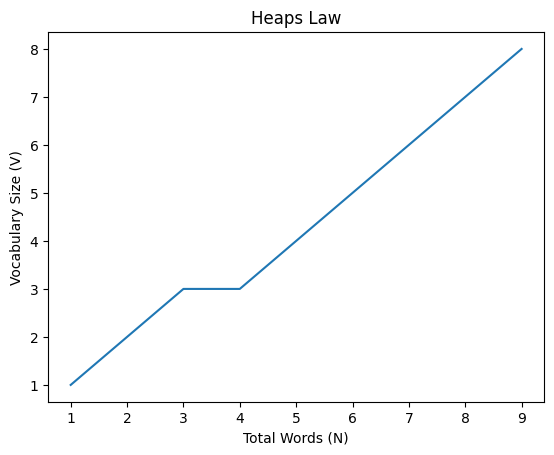

In [ ]:
import matplotlib.pyplot as plt

plt.plot(total_words, vocab_size)
plt.xlabel("Total Words (N)")
plt.ylabel("Vocabulary Size (V)")
plt.title("Heaps Law")
plt.show()

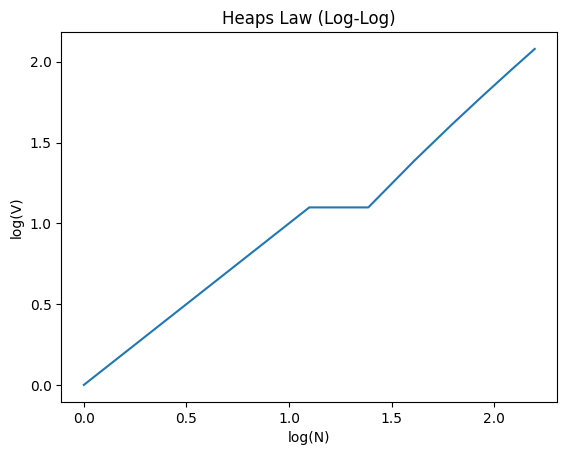

In [ ]:
import numpy as np

plt.plot(np.log(total_words), np.log(vocab_size))
plt.xlabel("log(N)")
plt.ylabel("log(V)")
plt.title("Heaps Law (Log-Log)")
plt.show()

In [ ]:
documents = {
    "doc1": "भारत एक सुंदर देश है",
    "doc2": "भारत में कई भाषाएँ हैं"
}

In [ ]:
inverted_index = {}

for doc_id, text in documents.items():
    import re
    text = re.sub(r'[^\u0900-\u097F\s]', '', text)

    words = text.split()

    for word in words:
        if word not in inverted_index:
            inverted_index[word] = []

        inverted_index[word].append(doc_id)

print(inverted_index)

{'भारत': ['doc1', 'doc2'], 'एक': ['doc1'], 'सुंदर': ['doc1'], 'देश': ['doc1'], 'है': ['doc1'], 'में': ['doc2'], 'कई': ['doc2'], 'भाषाएँ': ['doc2'], 'हैं': ['doc2']}
